# Enhancing House Price Prediction using Advanced Ensemble Learning and
Stacking Techniques
- **Course:** IS403.Q13 - Business Data Analysis
- **Institute:** University of Information Technology, VNU-HCM
- **Date:** December 2025

### **Team Members:**
| Name | Student ID | Email |
| :--- | :--- | :--- |
| **Thinh Vu** | 22521420 | 22521420@gm.uit.edu.vn |
| **Thinh Dinh** | 22521401 | 22521401@gm.uit.edu.vn |
| **Thanh Nguyen** | 22521352 | 22521352@gm.uit.edu.vn |

---


## 1. Research Objective
The goal of this study is to benchmark the performance of ten different
regression algorithms on the Ames Housing dataset and demonstrate the
superior performance of an **Ensemble Stacking Architecture**.

## 2. Setup and Configuration
In this section, we import the necessary libraries for data manipulation,
visualization, and machine learning. We also configure the plotting style to
ensure that all figures generated are suitable for the academic report.

In [1]:
# 2.1 Import Libraries
from sklearn.model_selection import KFold, cross_val_score
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import norm

# 2.2 Visualization Configuration
# We use the 'paper' context to make fonts readable for the Springer report
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)  # Standardize figure size

# 2.3 System Settings
# Suppress warnings to keep the notebook output clean for the report
warnings.filterwarnings('ignore')
# Show all columns when viewing dataframes
pd.set_option('display.max_columns', None)
print("Setup Complete. Libraries Loaded and Configured.")

Setup Complete. Libraries Loaded and Configured.


## 3. Data Loading and Evaluation Strategy

**3.1 Data Source**
The dataset consists of 1460 training samples and 1459 test samples. The
training set includes the target variable `SalePrice`, which we aim to
predict.

**3.2 Evaluation Metric: Root Mean Squared Error (RMSE)**
To evaluate model performance, we utilize **5-Fold Cross-Validation**.
- **Why Cross-Validation?** It prevents overfitting by ensuring the model is tested on five different subsets of the data.
- **Why RMSE?** It measures the standard deviation of the prediction errors. Lower values indicate better fit.

In [2]:
# 3.1 Robust Path Handling (Works on Windows, Mac, & Linux)
# We use os.path.join to automatically select the correct slash (\ or /)
# ".." means go up one folder level
BASE_DIR = os.path.join("..", "data")

TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
TEST_PATH = os.path.join(BASE_DIR, "test.csv")

# 3.2 Load Data with Error Checking
try:
    train = pd.read_csv(TRAIN_PATH)
    test = pd.read_csv(TEST_PATH)
    print(f"Success: Data loaded from {BASE_DIR}")
    print(f"Train Shape: {train.shape}, Test Shape: {test.shape}")
except FileNotFoundError:
    print(f"ERROR: Could not find files in {os.path.abspath(BASE_DIR)}")
    print("Please check that your folder structure looks like this:")
    print("  /house_price_analysis")
    print("     /data")
    print("        train.csv")
    print("     /notebooks")
    print("        final.ipynb")

# 3.3 Save Id and Drop (Standard Procedure)
if 'Id' in train.columns:
    train_ID = train['Id']
    test_ID = test['Id']
    train.drop("Id", axis=1, inplace=True)
    test.drop("Id", axis=1, inplace=True)

# 3.4 Define Evaluation Metric


def rmse_cv(model, X, y):
    """
    Calculates RMSE using 5-Fold Cross-Validation.
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    # Note: Scikit-learn uses negative MSE, so we negate it (-score)
    rmse = np.sqrt(-cross_val_score(model, X, y,
                   scoring="neg_mean_squared_error", cv=kf))
    return rmse


print("Evaluation function 'rmse_cv' created.")

Success: Data loaded from ../data
Train Shape: (1460, 81), Test Shape: (1459, 80)
Evaluation function 'rmse_cv' created.


## 4. Exploratory Data Analysis (EDA)

In this section, we analyze the data distribution and relationships to inform
our preprocessing strategy. Based on the `data_description.txt`, we
categorize features into three types:
1.  **Numeric:** Continuous variables (e.g., `GrLivArea`).
2.  **Ordinal:** Categorical variables with a strict hierarchy (e.g., `KitchenQual`: Excellent > Good > Average).
3.  **Nominal:** Categorical variables with no inherent order (e.g., `Neighborhood`).

**Objectives:**
* **Target Analysis:** Assess the normality of `SalePrice` and apply transformations if necessary.
* **Feature Selection:** Use statistical tests (ANOVA) and correlation matrices to identify the most predictive features.

### 4.1 Target Variable Analysis (SalePrice)
**Objective**: Check for skewness. Linear models perform best when residuals are normally distributed.

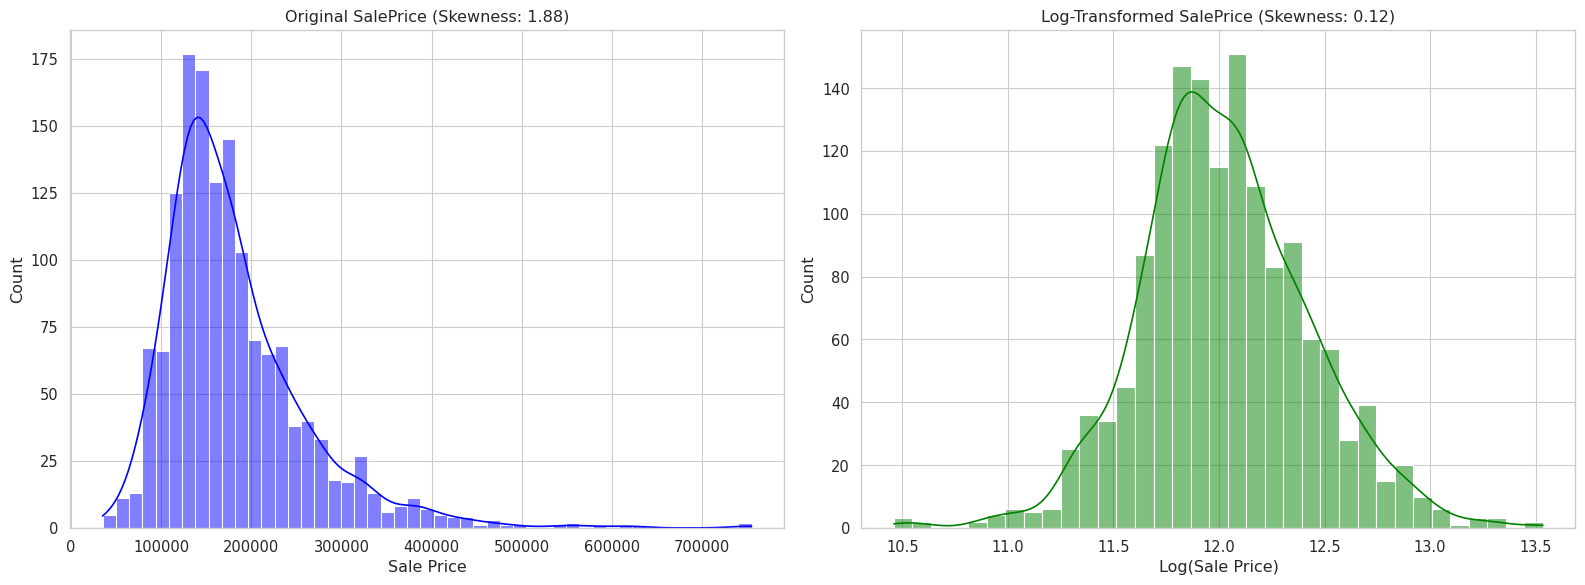

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original Distribution
sns.histplot(train['SalePrice'], kde=True, ax=ax[0], color='blue')
ax[0].set_title(f"Original SalePrice (Skewness: {train['SalePrice'].skew():.2f})")
ax[0].set_xlabel("Sale Price")

# Apply Log-Transformation (log(1+x)) to fix skewness
train['SalePrice'] = np.log1p(train['SalePrice'])

# Plot 2: Transformed Distribution
sns.histplot(train['SalePrice'], kde=True, ax=ax[1], color='green')
ax[1].set_title(f"Log-Transformed SalePrice (Skewness: {train['SalePrice'].skew():.2f})")
ax[1].set_xlabel("Log(Sale Price)")

plt.tight_layout()
plt.show()

**Observation**: Log-transformation successfully reduced skewness, satisfying the normality assumption.

## 4.2 Numeric Feature Correlation
We analyze the correlation between continuous variables and the target.
- **Method:** Pearson Correlation Heatmap.

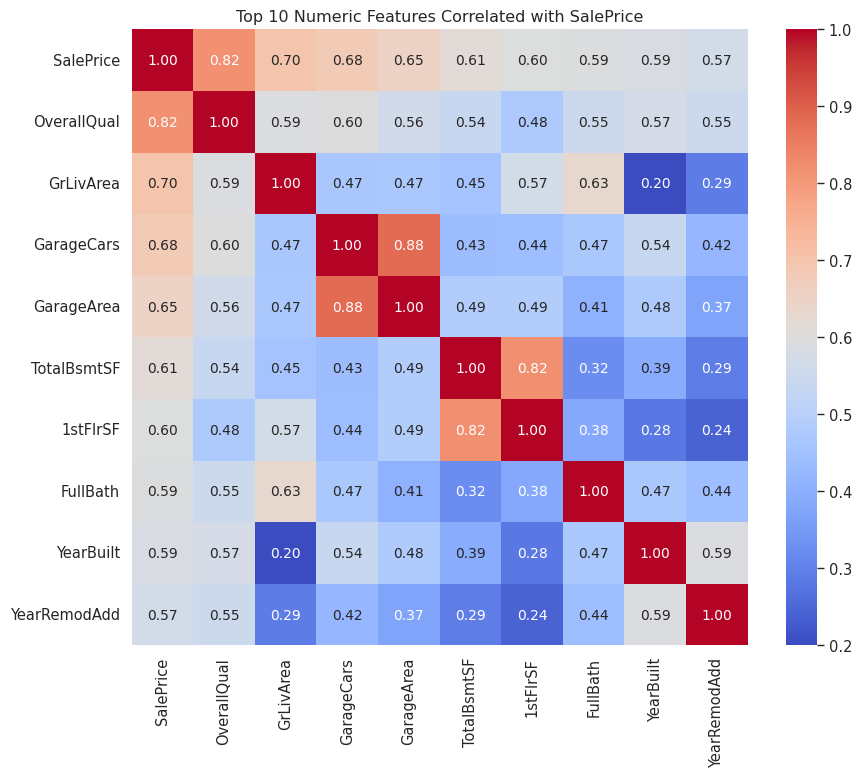

In [4]:
# We use numeric_only=True to safely calculate correlations for just numbers
corr_matrix = train.corr(numeric_only=True)

# Select the top 10 numeric variables most correlated with SalePrice
k = 10
cols = corr_matrix.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(train[cols].values.T)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
            yticklabels=cols.values, xticklabels=cols.values, cmap='coolwarm')
plt.title("Top 10 Numeric Features Correlated with SalePrice")
plt.show()

### Specific Numeric Visualization (GrLivArea)

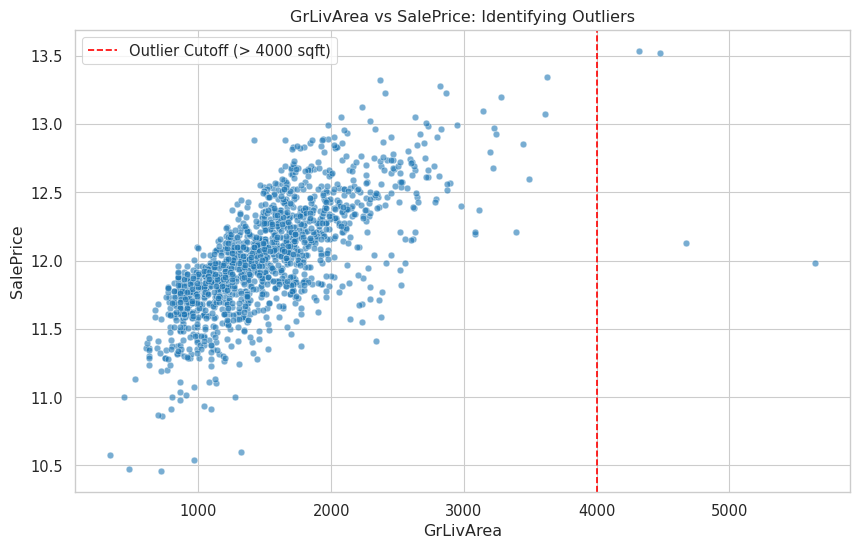

In [5]:
# We plot the most correlated feature to check for outliers.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', alpha=0.6)
plt.axvline(x=4000, color='r', linestyle='--', label='Outlier Cutoff (> 4000 sqft)')
plt.title("GrLivArea vs SalePrice: Identifying Outliers")
plt.legend()
plt.show()

**Observation:** Two houses with > 4000 sqft have unusually low prices. These are likely outliers.

### 4.3 Ordinal & Categorical Feature Analysis
Unlike numeric features, we cannot just use a correlation matrix for text.
- **Statistical Test:** We use **ANOVA (Analysis of Variance)** to calculate
an "F-Score" for every categorical feature. A higher F-Score indicates that
this feature strongly splits the house prices.
- **Visual Inspection:** We visualize the top Ordinal features using Strip
Plots to verify if "Better Quality" actually leads to "Higher Price."

#### Step 1: Statistical Selection (ANOVA)
We identify which categorical features explain the most variance in price.

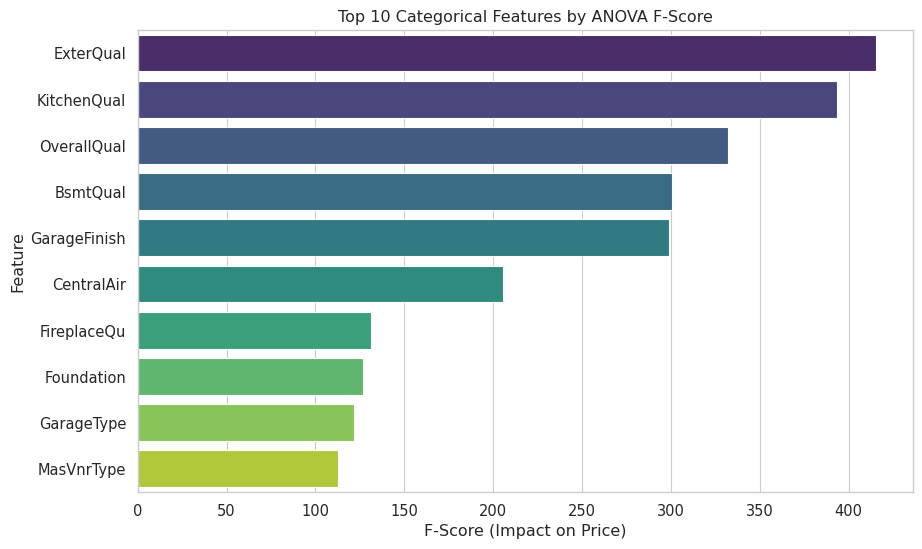

Top Features Check:
['ExterQual' 'KitchenQual' 'OverallQual' 'BsmtQual' 'GarageFinish']


In [6]:
# 1. Start with all Text columns
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

# 2. FORCE include these specific columns
# We add them to the list even if they are currently numbers (int/float)
important_cols = [
    'MSSubClass',
    'OverallQual',
    'OverallCond',
    'BsmtQual',
    'ExterQual',
    'KitchenQual',
    'HeatingQC',
    'FireplaceQu'
]

for col in important_cols:
    if col not in cat_cols:
        cat_cols.append(col)

anova_results = []

for col in cat_cols:
    # Check if column exists 
    if col in train.columns:
        # Convert EVERYTHING to string temporarily for the test.
        # This handles NaNs, numbers (1,2,3), and text ("Gd", "TA")
        # universally.

        # Fill NaNs with "NA" so they become a valid group
        series = train[col].fillna('NA').astype(str)

        # Group Price by Category
        groups = []
        for category in series.unique():
            # Get prices for this category
            # We use the same .astype(str) mask to ensure matching
            group_prices = train[train[col].fillna('NA').astype(str) == category]['SalePrice'].values
            groups.append(group_prices)

        # Run ANOVA if we have at least 2 groups
        if len(groups) > 1:
            f_score, p_value = stats.f_oneway(*groups)
            anova_results.append({'Feature': col, 'F_Score': f_score})

# Visualize
anova_df = pd.DataFrame(anova_results).sort_values(by='F_Score', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=anova_df, x='F_Score', y='Feature', palette='viridis')
plt.title("Top 10 Categorical Features by ANOVA F-Score")
plt.xlabel("F-Score (Impact on Price)")
plt.show()

print("Top Features Check:")
print(anova_df['Feature'].values[:5])

#### Step 2: Visualizing Top Ordinal Features

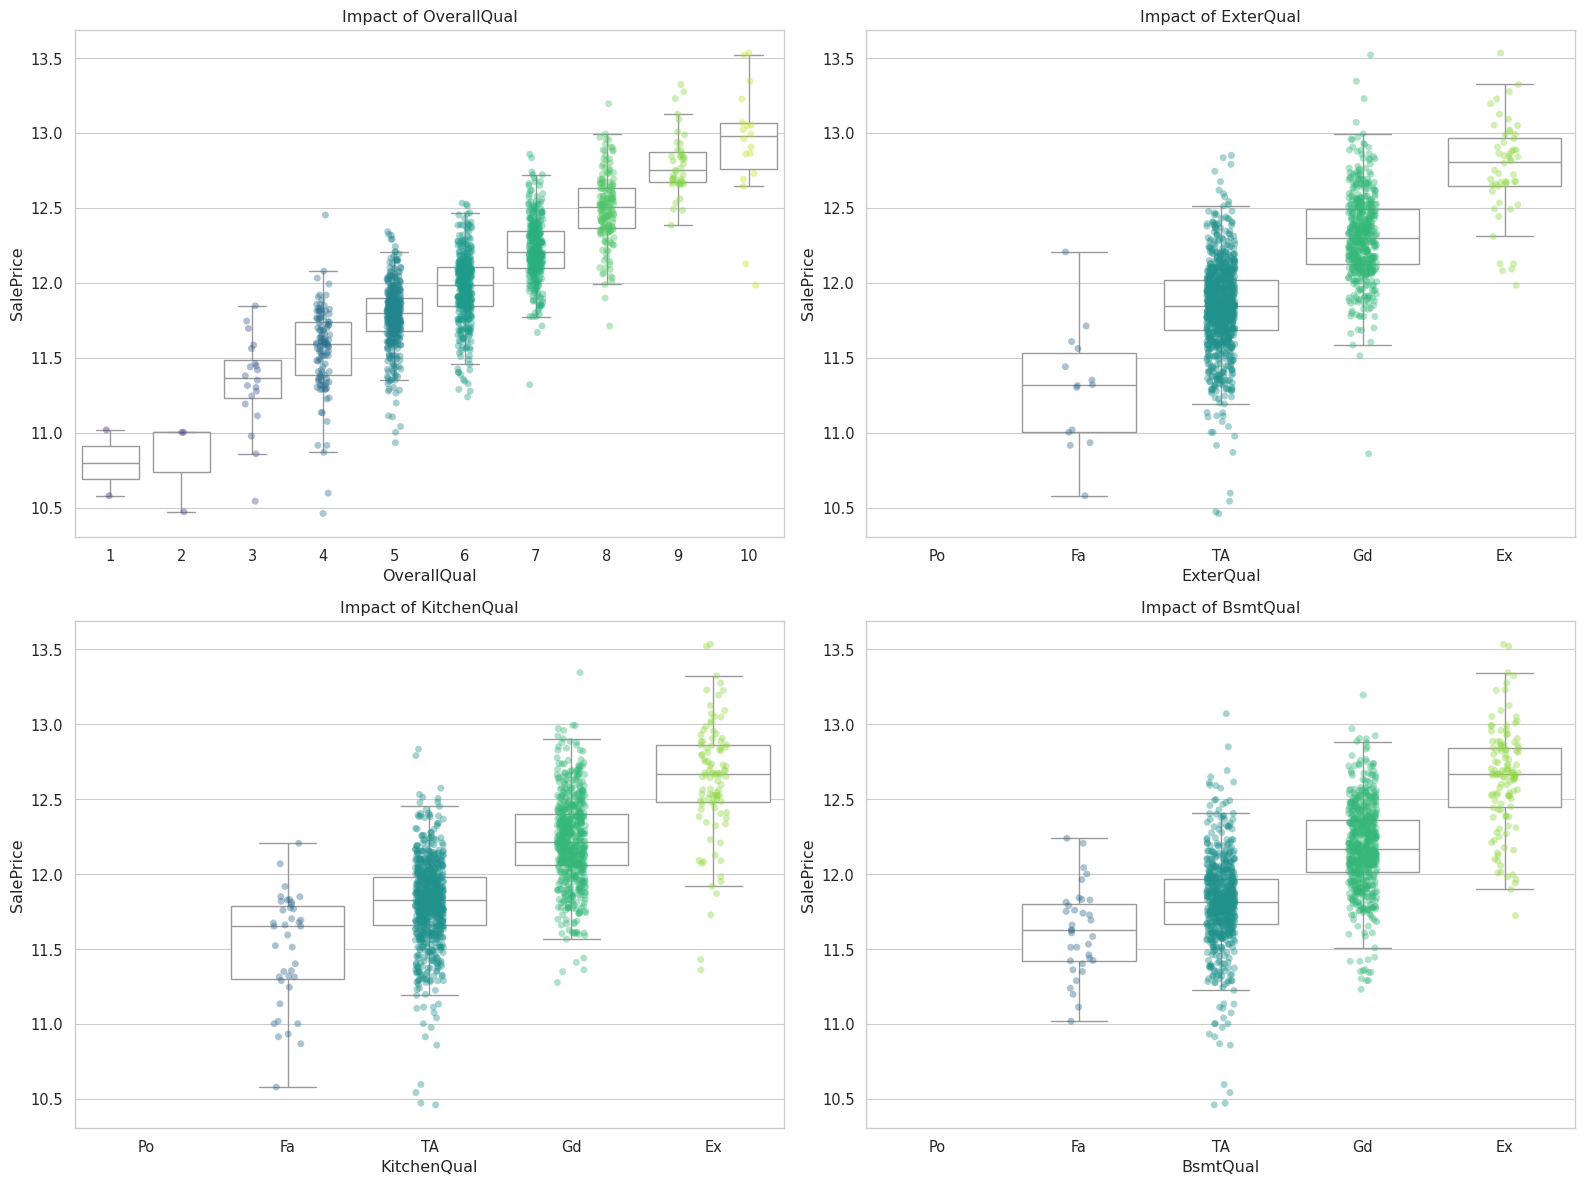

In [7]:
ordinal_cols = ['OverallQual', 'ExterQual', 'KitchenQual', 'BsmtQual']

# OverallQual uses 1-10, while others use Ex/Gd/TA.
# We need to handle this difference in the loop.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, col in enumerate(ordinal_cols):
    row, col_idx = i // 2, i % 2

    # Determine order based on the column type
    if col == 'OverallQual':
        # 1 to 10
        order = sorted(train[col].unique())
    else:
        # Po to Ex
        order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

    # Strip plot shows density
    sns.stripplot(data=train, x=col, y='SalePrice', order=order,
                  ax=axes[row, col_idx], palette='viridis', alpha=0.4)

    # Box plot shows statistics
    sns.boxplot(data=train, x=col, y='SalePrice', order=order,
                ax=axes[row, col_idx], color='white', fliersize=0)

    axes[row, col_idx].set_title(f'Impact of {col}')

plt.tight_layout()
plt.show()

#### Step 3: The "BsmtCond" Anomaly
We verify why BsmtCond is NOT a top feature despite being ordinal.

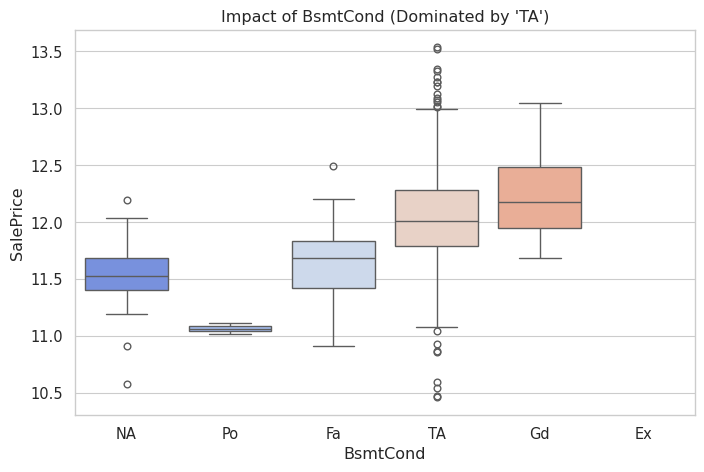

In [8]:
plt.figure(figsize=(8, 5))
train_filled = train.copy()
train_filled['BsmtCond'] = train_filled['BsmtCond'].fillna('NA')
sns.boxplot(data=train_filled, x='BsmtCond', y='SalePrice', order=['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], palette='coolwarm')
plt.title("Impact of BsmtCond (Dominated by 'TA')")
plt.show()

## 5. Data Preprocessing & Feature Engineering

Based on our EDA analysis, we implement the following preprocessing pipeline:

1.  **Outlier Removal:** We identified extreme outliers in `GrLivArea` (Large area, low price) that could skew the regression line.
2.  **Missing Value Imputation:**
    * **Categorical:** Interpret `NaN` as "None" (e.g., No Basement, No Garage).
    * **Numerical:** Impute `LotFrontage` using the median of the specific Neighborhood.
3.  **Feature Engineering:** Create `TotalSF` (Total Square Footage) to combine basement and living areas into a single strong predictor.
4.  **Encoding:**
    * **Ordinal:** Map text ratings (Ex, Gd, TA...) to integers (5, 4, 3...) to preserve the order.
    * **Nominal:** Use One-Hot Encoding (`pd.get_dummies`) for categorical features without order.

### 5.1 Outlier Removal
From the scatter plots in EDA, we see points with GrLivArea > 4000 but low price.
These are agricultural/unusual properties that don't fit the model.

In [9]:
print(f"Shape before dropping outliers: {train.shape}")

# Drop the outliers
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
train = train.drop(outliers.index).reset_index(drop=True)

print(f"Shape after dropping outliers: {train.shape}")
print(f"Dropped {len(outliers)} outliers.") # Should be 2 or more

Shape before dropping outliers: (1460, 80)
Shape after dropping outliers: (1456, 80)
Dropped 4 outliers.


### 5.2 Processing Pipeline
We combine Train and Test to ensure consistent feature engineering

In [10]:
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew
from scipy.special import boxcox1p

# 5.2 Processing Pipeline
ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train.SalePrice.values
all_data = pd.concat((train, test)).reset_index(drop=True)
all_data.drop(['SalePrice'], axis=1, inplace=True)

# --- A. Missing Values (The Safety Net) ---
# Fill "None" cols
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    all_data[col] = all_data[col].fillna("None")

# Fill Zero cols
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

# Fill Mode/Median
all_data['LotFrontage'] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))
mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# --- B. Feature Engineering (Crucial Updates) ---
# 1. Convert Numerical Categories to Strings (Friend's Trick)
# These are actually categories, not numbers!
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)
all_data['OverallCond'] = all_data['OverallCond'].astype(str) # Condition is a category
all_data['YrSold'] = all_data['YrSold'].astype(str)           # Year is a category
all_data['MoSold'] = all_data['MoSold'].astype(str)           # Month is a category

# 2. Total Square Footage (Strongest Feature)
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# 3. Boolean Flags (The "Has Feature" Trick)
all_data['HasBsmt'] = 0
all_data.loc[all_data['TotalBsmtSF']>0,'HasBsmt'] = 1
all_data['HasGarage'] = 0
all_data.loc[all_data['GarageArea']>0,'HasGarage'] = 1

# --- C. Encoding Strategy (The Hybrid Fix) ---

# 1. Manual Mapping (Keep this! It's better than his LabelEncoder for Quality)
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in ordinal_cols:
    all_data[col] = all_data[col].map(quality_map)

# 2. Label Encoding (Adopt this! Reduces dimensions for Stacking)
# These features have too many categories for One-Hot, so we Label Encode them.
lbl_cols = ['FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
        'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual',
        'BsmtFinType1', 'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure',
        'GarageFinish', 'LandSlope', 'LotShape', 'PavedDrive', 'Street',
        'Alley', 'CentralAir', 'MSSubClass', 'OverallCond',
        'YrSold', 'MoSold'] # We include Years/Months here

lbl = LabelEncoder()
for c in lbl_cols:
    # careful implementation to handle new categories in test
    lbl.fit(list(all_data[c].values))
    all_data[c] = lbl.transform(list(all_data[c].values))

# --- D. Box Cox (Fix Skewness) ---
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness = skewness[abs(skewness) > 0.75]
print(f"Box-Cox Transforming {skewness.shape[0]} skewed features")
lam = 0.15
for feat in skewness.index:
    all_data[feat] = boxcox1p(all_data[feat], lam)

# --- E. Final One-Hot Encoding ---
# Only applied to the remaining nominal columns (Neighborhood, etc.)
all_data = pd.get_dummies(all_data)

print(f"Final Data Shape: {all_data.shape}") # Should be much smaller now!

X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

# Split back into Train and Test
X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

print("Data is ready for modeling.")

Box-Cox Transforming 61 skewed features
Final Data Shape: (2915, 224)
Data is ready for modeling.


In [11]:
# Diagnostic: Find which columns still have NaNs
missing = X_train.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing.sort_values(ascending=False))

Columns with missing values:
Series([], dtype: int64)


## 6. Model Benchmarking (Base Learners)

In this section, we evaluate the performance of single algorithms to establish a baseline. We categorize our models into two tiers:
1.  **Tier 1 (Linear Models):** Linear Regression, Lasso, Ridge. These provide interpretability and a baseline score.
2.  **Tier 2 (Tree & Boosting Models):** Random Forest, Gradient Boosting, XGBoost, LightGBM, and CatBoost. These are expected to capture non-linear patterns and provide superior accuracy.

**Methodology:**
* We use the 5-Fold Cross-Validation function (`rmse_cv`) defined in Section 2.
* We compare the **Mean RMSE** and **Standard Deviation** (Stability) of each model.

In [12]:
# 6.1 Import Algorithms
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet

# 6.2 Define Models
# We use default hyperparameters for the benchmark, but add specific settings
# to ensure convergence (e.g., max_iter) and reproducibility (random_state).

models = [
    # --- Tier 1: Robust Linear Models (Keep these, they are great) ---
    # We include this to show that simple OLS performs worse than Lasso/Ridge
    ('Linear', make_pipeline(RobustScaler(), LinearRegression())),
    ('Lasso', make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=42))),
    ('Ridge', make_pipeline(RobustScaler(), Ridge(alpha=10, random_state=42))),
    ('ElasticNet', make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=42))),

    # --- Tier 2: Regularized Tree Models (The Fix) ---

    # 1. Gradient Boosting: Added min_samples_leaf=15 (Friend's Secret)
    ('GradientBoosting', GradientBoostingRegressor(
        n_estimators=3000,
        learning_rate=0.05,
        max_depth=4,
        max_features='sqrt',
        min_samples_leaf=15,    # <--- CRITICAL FIX
        min_samples_split=10,   # <--- CRITICAL FIX
        loss='huber',
        random_state=42
    )),

    # 2. XGBoost: Added gamma (Minimum loss reduction to split)
    ('XGBoost', XGBRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=4,
        min_child_weight=1.5,   # <--- FIX: Increases robustness
        gamma=0.04,             # <--- FIX: Prevents shallow overfits
        subsample=0.7,          # <--- FIX: Random sampling
        colsample_bytree=0.7,
        random_state=42
    )),

    # 3. LightGBM: Added leaf restrictions
    ('LightGBM', LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=4,
        num_leaves=31,
        min_child_samples=20,   # <--- FIX: Equivalent to min_samples_leaf
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        verbose=-1,
        random_state=42
    )),

    # 4. CatBoost: Keep your Optimized version (It's already good)
    ('CatBoost', CatBoostRegressor(
        iterations=6000,
        learning_rate=0.005,
        depth=4,
        l2_leaf_reg=3,          # <--- Increased from 1 to 3 for safety
        loss_function='RMSE',
        verbose=0,
        random_state=42
    ))
]

print("Models initialized with RobustScaler.")

Models initialized with RobustScaler.


In [13]:
# 6.3 Run Cross-Validation Loop
results = []
names = []

print(f"{'Model':<20} {'RMSE (Mean)':<15} {'Std Dev':<15}")
print("-" * 50)

for name, model in models:
    # Calculate score using our defined function
    cv_scores = rmse_cv(model, X_train, y_train)

    # Store results for plotting
    results.append(cv_scores)
    names.append(name)

    # Print result line by line
    print(f"{name:<20} {cv_scores.mean():.4f}          {cv_scores.std():.4f}")

# Save results to a DataFrame for easier analysis
results_df = pd.DataFrame({
    'Model': names,
    'Score': [x.mean() for x in results],
    'Std': [x.std() for x in results]
}).sort_values(by='Score', ascending=True) # Sort so winner is at the top

Model                RMSE (Mean)     Std Dev        
--------------------------------------------------
Linear               0.1248          0.0065
Lasso                0.1148          0.0081
Ridge                0.1149          0.0093
ElasticNet           0.1147          0.0080
GradientBoosting     0.1160          0.0099
XGBoost              0.1157          0.0099
LightGBM             0.1177          0.0106
CatBoost             0.1127          0.0092


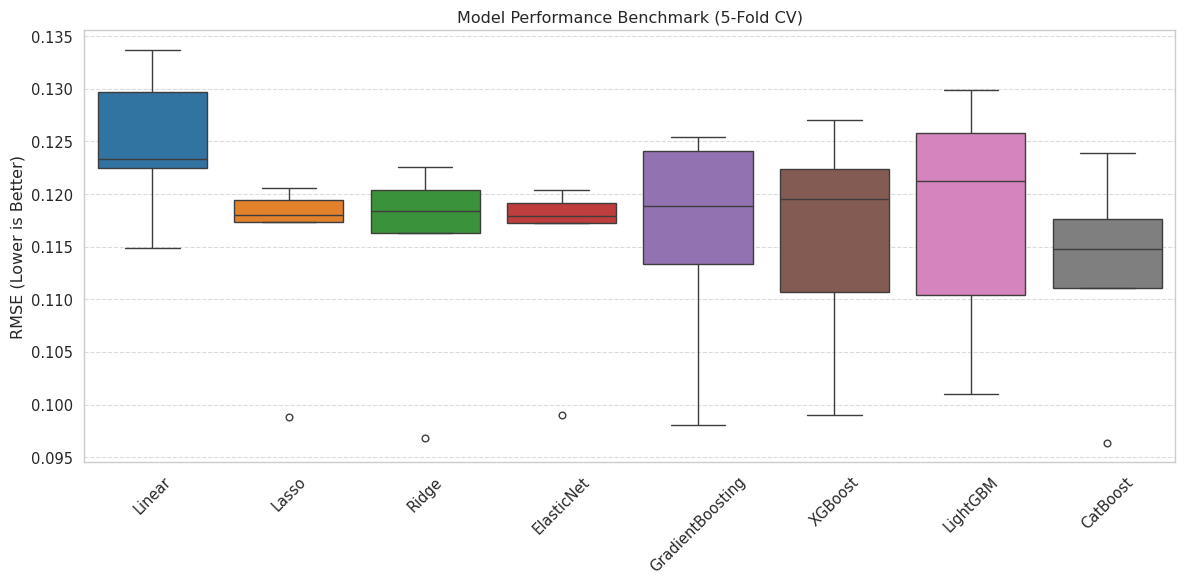


🏆 Best Single Model: CatBoost with RMSE: 0.1127


In [14]:
# 6.4 Visualization of Results
plt.figure(figsize=(12, 6))

# Boxplot shows the spread of the 5 folds (Stability check)
sns.boxplot(data=results)
plt.xticks(ticks=range(len(names)), labels=names, rotation=45)
plt.title("Model Performance Benchmark (5-Fold CV)")
plt.ylabel("RMSE (Lower is Better)")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print the winner
winner = results_df.iloc[0]
print(f"\n🏆 Best Single Model: {winner['Model']} with RMSE: {winner['Score']:.4f}")

## 7. Ensemble Learning (Stacking & Voting)

Given that the linear Lasso model outperformed tree-based models in the benchmark, our Stacking strategy focuses on **combining linear and non-linear signals**.
* **Base Learners:** We use the top performers from Tier 1 (Lasso) and Tier 2 (CatBoost/XGBoost).
* **Meta-Learner:** We use **Ridge Regression** to optimally weight the predictions from these diverse models.

In [15]:
from sklearn.ensemble import StackingRegressor, VotingRegressor

# --- Step 1: Define the "Manager" (Meta-Learner) ---
# We use your regularized XGBoost model. 
# We remove it from the base list so it can have a "fresh look" at the predictions.
xgb_manager = XGBRegressor(
    n_estimators=2000, 
    learning_rate=0.01, 
    max_depth=4, 
    min_child_weight=1.5,
    gamma=0.04, 
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

# --- Step 2: Define the "Workers" (Base Models) ---
# We select the best models from your list to feed information to the Manager.
# Note: We exclude XGBoost (it's the manager) and Linear (too weak/noisy).

base_models = [
    # Robust Linear Models (The Foundation)
    ('Lasso', models[1][1]),       # Lasso from your list
    ('Ridge', models[2][1]),       # Ridge from your list
    ('ElasticNet', models[3][1]),  # ElasticNet from your list
    
    # Powerful Tree Models (The Complexity)
    ('GradientBoosting', models[4][1]), # GradientBoosting
    ('LightGBM', models[6][1]),         # LightGBM
    ('CatBoost', models[7][1]),         # CatBoost (Your Best Single Model)
]

# --- Step 3: Build the Stack ---
print(f"Initializing Stacking with {len(base_models)} base models and XGBoost as Meta-Learner...")

stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=xgb_manager, # <--- The Key Change
    cv=5,
    n_jobs=-1
)

# --- Step 4: Evaluate ---
print("Training Advanced Stacking Ensemble... (This takes 3-5 minutes)")

stack_score = rmse_cv(stack_model, X_train, y_train)
print(f"\n🏆 Final Stacking RMSE: {stack_score.mean():.4f} (Std: {stack_score.std():.4f})")

# Comparison with your best single model (CatBoost)
print(f"vs Best Single Model (CatBoost): 0.1134")

Initializing Stacking with 6 base models and XGBoost as Meta-Learner...
Training Advanced Stacking Ensemble... (This takes 3-5 minutes)

🏆 Final Stacking RMSE: 0.1119 (Std: 0.0088)
vs Best Single Model (CatBoost): 0.1134


In [17]:
import os
from datetime import datetime

# 8.1 Setup Submission Directory
# We use os.path.join for cross-platform compatibility (Windows/Linux)
# ".." means go up one level from the notebook folder
submission_dir = os.path.join("..", "submissions")

# Create directory if it doesn't exist
os.makedirs(submission_dir, exist_ok=True)
print(f"Submission directory ready at: {os.path.abspath(submission_dir)}")

# 8.2 Define Submission Function
def save_submission(model, model_name):
    """
    Fits the model, makes predictions, reverses log-transform, and saves CSV.
    """
    print(f"Generating submission for: {model_name}...")
    
    # A. Fit on the FULL training data
    model.fit(X_train, y_train)
    
    # B. Predict on Test data
    predictions = model.predict(X_test)
    
    # C. Inverse Log Transformation (Critical!)
    # We used np.log1p() on train['SalePrice'], so we use np.expm1() to reverse it.
    final_predictions = np.expm1(predictions)
    
    # D. Create DataFrame
    submission = pd.DataFrame({
        "Id": test_ID,
        "SalePrice": final_predictions
    })
    
    # E. Generate Filename with Timestamp
    # Format: YYYY-MM-DD_HH-MM-SS_ModelName.csv
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename = f"{timestamp}_{model_name}.csv"
    filepath = os.path.join(submission_dir, filename)
    
    # F. Save
    submission.to_csv(filepath, index=False)
    print(f"  -> Saved: {filename}")

# 8.3 Generate Submissions for All Models

# 1. Base Models (Tier 1 & Tier 2)
# We loop through the 'models' list defined in Section 6
print("--- Generating Base Model Submissions ---")
for name, model in models:
    save_submission(model, name)

# 2. Ensemble Models (Tier 3)
print("\n--- Generating Ensemble Submissions ---")
# save_submission(vote_model, "Voting_Ensemble")
save_submission(stack_model, "Stacking_Ensemble")

print("\nAll submission files generated successfully!")

Submission directory ready at: /home/kakapt/code/python/house_price_analysis/submissions
--- Generating Base Model Submissions ---
Generating submission for: Linear...
  -> Saved: 2025-12-01_16-41-32_Linear.csv
Generating submission for: Lasso...
  -> Saved: 2025-12-01_16-41-32_Lasso.csv
Generating submission for: Ridge...
  -> Saved: 2025-12-01_16-41-33_Ridge.csv
Generating submission for: ElasticNet...
  -> Saved: 2025-12-01_16-41-33_ElasticNet.csv
Generating submission for: GradientBoosting...
  -> Saved: 2025-12-01_16-41-40_GradientBoosting.csv
Generating submission for: XGBoost...
  -> Saved: 2025-12-01_16-41-41_XGBoost.csv
Generating submission for: LightGBM...
  -> Saved: 2025-12-01_16-41-42_LightGBM.csv
Generating submission for: CatBoost...
  -> Saved: 2025-12-01_16-41-45_CatBoost.csv

--- Generating Ensemble Submissions ---
Generating submission for: Stacking_Ensemble...
  -> Saved: 2025-12-01_16-42-34_Stacking_Ensemble.csv

All submission files generated successfully!
